## Healthcare Facility Distribution in Canada
This project analyzes healthcare facilities across Canada.


Step 1: Data Loading
The dataset used in this project is the Open Database of Healthcare Facilities (ODHF). It contains information about healthcare facilities across Canada, including facility names, types, locations, and geographic coordinates.

In [1]:
import pandas as pd                
import numpy as np                 
import matplotlib.pyplot as plt    
import seaborn as sns              
from sklearn.cluster import KMeans 

In [2]:
df = pd.read_csv("odhf_v1.csv", encoding="latin1", sep=",", engine="python")

In [3]:
df.head()

,index,facility_name,source_facility_type,odhf_facility_type,provider,unit,street_no,street_name,postal_code,city,province,source_format_str_address,CSDname,CSDuid,Pruid,latitude,longitude
0,1,Advanced Facial & Nasal Surgery Centre,other,Ambulatory health care services,Canadian Institute for Health Information,NaN,NaN,NaN,T5M 4G5,edmonton,ab,NaN,Edmonton,NaN,48.0,NaN,NaN
1,10,Alberta Children's Hospital,pediatric,Hospitals,Public Health Agency of Canada,NaN,28,oki dr nw,T3B 6A8,calgary,ab,28 Oki Dr NW,Calgary,4806016.0,48.0,51.074582,-114.148426
2,100,Devon General Hospital,general,Hospitals,Public Health Agency of Canada,NaN,101,erie st s,T9G 1A6,devon,ab,101 erie st. s. devon ab t9g 1a6,Devon,4811018.0,48.0,53.351493,-113.730785
3,1000,Kimbelee Place,NaN,Nursing and residential care facilities,Province of British Columbia,NaN,12935,96 ave,V3V 7K6,surrey,bc,12935 96th ave surrey bc v3v 7k6,Surrey,5915004.0,59.0,49.177418,-122.864118
4,1001,Kimberley Special Care Home,NaN,Nursing and residential care facilities,Province of British Columbia,NaN,386,2 ave,V1A 2Z6,kimberley,bc,386 2 ave kimberley bc v1a 2z6,Kimberley,5901028.0,59.0,49.689998,-115.989647


In [4]:
df.shape

(7033, 17)

In [5]:
df.columns

Index(['index', 'facility_name', 'source_facility_type', 'odhf_facility_type',
       'provider', 'unit', 'street_no', 'street_name', 'postal_code', 'city',
       'province', 'source_format_str_address', 'CSDname', 'CSDuid', 'Pruid',
       'latitude', 'longitude'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7033 entries, 0 to 7032
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   index                      7033 non-null   object 
 1   facility_name              5010 non-null   object 
 2   source_facility_type       3803 non-null   object 
 3   odhf_facility_type         5010 non-null   object 
 4   provider                   5010 non-null   object 
 5   unit                       3 non-null      object 
 6   street_no                  4498 non-null   object 
 7   street_name                4541 non-null   object 
 8   postal_code                5010 non-null   object 
 9   city                       4994 non-null   object 
 10  province                   5010 non-null   object 
 11  source_format_str_address  2023 non-null   object 
 12  CSDname                    4972 non-null   object 
 13  CSDuid                     4571 non-null   float

In [7]:
df.isnull().sum()

index                           0
facility_name                2023
source_facility_type         3230
odhf_facility_type           2023
provider                     2023
unit                         7030
street_no                    2535
street_name                  2492
postal_code                  2023
city                         2039
province                     2023
source_format_str_address    5010
CSDname                      2061
CSDuid                       2462
Pruid                        2023
latitude                     2462
longitude                    2462
dtype: int64

In [8]:
df.columns = df.columns.str.strip().str.lower()

In [9]:
df["city"] = df["city"].str.strip().str.title()
df["province"] = df["province"].str.strip().str.upper()

In [10]:
df["source_facility_type"] = df["source_facility_type"].fillna(df["odhf_facility_type"])

In [11]:
df = df.drop(columns=["unit"], errors="ignore")

In [12]:
df_geo = df.dropna(subset=["latitude","longitude"])

In [13]:
df_geo.head()

,index,facility_name,source_facility_type,odhf_facility_type,provider,street_no,street_name,postal_code,city,province,source_format_str_address,csdname,csduid,pruid,latitude,longitude
1,10,Alberta Children's Hospital,pediatric,Hospitals,Public Health Agency of Canada,28,oki dr nw,T3B 6A8,Calgary,AB,28 Oki Dr NW,Calgary,4806016.0,48.0,51.074582,-114.148426
2,100,Devon General Hospital,general,Hospitals,Public Health Agency of Canada,101,erie st s,T9G 1A6,Devon,AB,101 erie st. s. devon ab t9g 1a6,Devon,4811018.0,48.0,53.351493,-113.730785
3,1000,Kimbelee Place,Nursing and residential care facilities,Nursing and residential care facilities,Province of British Columbia,12935,96 ave,V3V 7K6,Surrey,BC,12935 96th ave surrey bc v3v 7k6,Surrey,5915004.0,59.0,49.177418,-122.864118
4,1001,Kimberley Special Care Home,Nursing and residential care facilities,Nursing and residential care facilities,Province of British Columbia,386,2 ave,V1A 2Z6,Kimberley,BC,386 2 ave kimberley bc v1a 2z6,Kimberley,5901028.0,59.0,49.689998,-115.989647
5,1002,Kinetic Energy Health and Wellness Centre,Ambulatory health care services,Ambulatory health care services,Province of British Columbia,207-450,lansdowne street,V2C 1Y4,Kamloops,BC,207-450 lansdowne street kamloops bc v2c 1y4,Kamloops,5933042.0,59.0,50.677060,-120.329500


In [14]:
df["odhf_facility_type"].value_counts()

odhf_facility_type
Nursing and residential care facilities    2871
Ambulatory health care services            1407
Hospitals                                   732
Name: count, dtype: int64

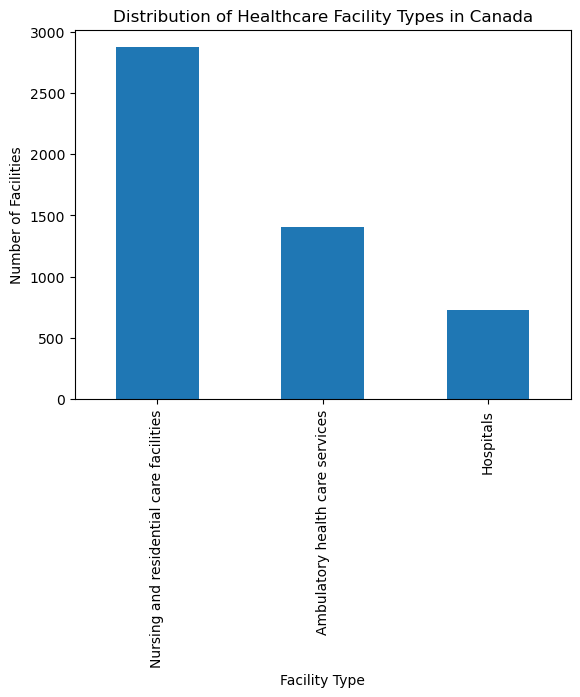

In [15]:
df["odhf_facility_type"].value_counts().plot(kind="bar")

plt.title("Distribution of Healthcare Facility Types in Canada")
plt.xlabel("Facility Type")
plt.ylabel("Number of Facilities")

plt.show()

In [16]:
df["province"].value_counts()

province
ON    2634
BC    1308
AB     273
SK     170
MB     151
NS     141
PE      95
NB      91
NL      78
QC      60
NT       6
NU       3
Name: count, dtype: int64

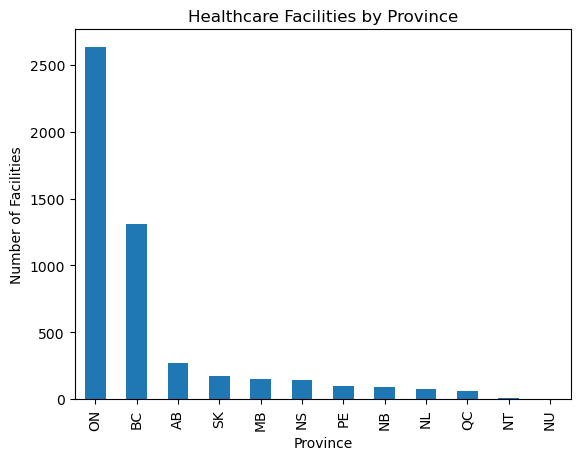

In [17]:
df["province"].value_counts().plot(kind="bar")

plt.title("Healthcare Facilities by Province")
plt.xlabel("Province")
plt.ylabel("Number of Facilities")

plt.show()

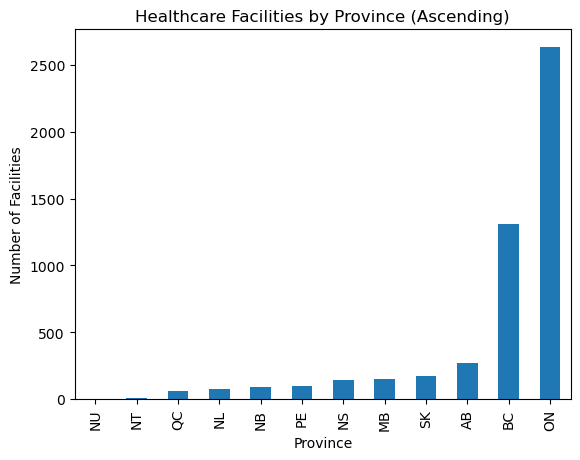

In [18]:
df["province"].value_counts().sort_values().plot(kind="bar")

plt.title("Healthcare Facilities by Province (Ascending)")
plt.xlabel("Province")
plt.ylabel("Number of Facilities")

plt.show()

In [19]:
df["city"].value_counts().head(10)

city
Toronto        383
Ottawa         177
Vancouver      160
Victoria       120
Hamilton       113
Surrey          91
London          69
Calgary         61
Burnaby         60
Mississauga     58
Name: count, dtype: int64

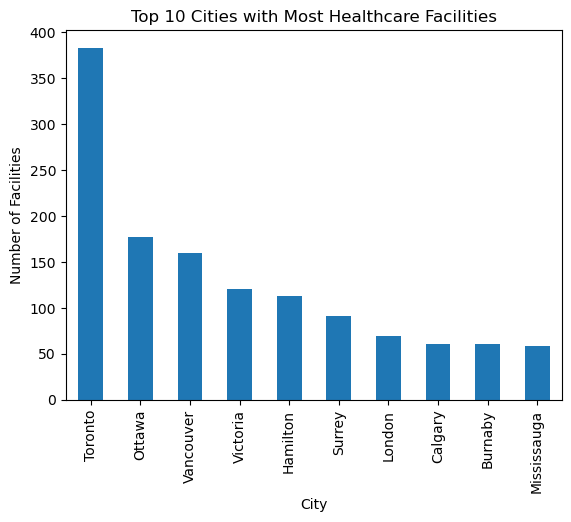

In [20]:
df["city"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Cities with Most Healthcare Facilities")
plt.xlabel("City")
plt.ylabel("Number of Facilities")
plt.show()

In [21]:
pd.crosstab(df["province"], df["odhf_facility_type"])

odhf_facility_type,Ambulatory health care services,Hospitals,Nursing and residential care facilities
province,,,
AB,41,124,108
BC,227,98,983
MB,25,85,41
NB,12,16,63
NL,27,29,22
NS,5,33,103
NT,1,5,0
NU,0,3,0
ON,960,234,1440


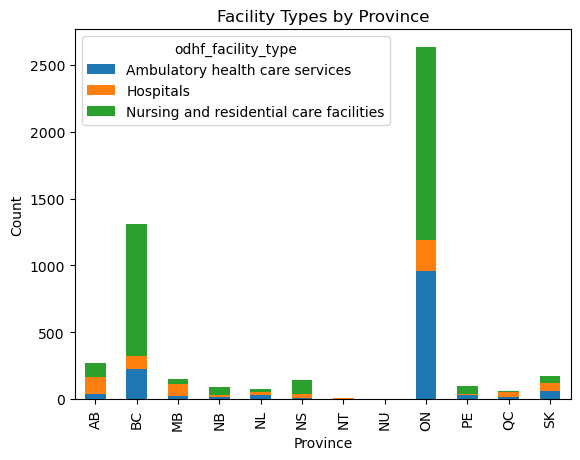

In [22]:
pd.crosstab(df["province"], df["odhf_facility_type"]).plot(kind="bar", stacked=True)

plt.title("Facility Types by Province")
plt.xlabel("Province")
plt.ylabel("Count")
plt.show()

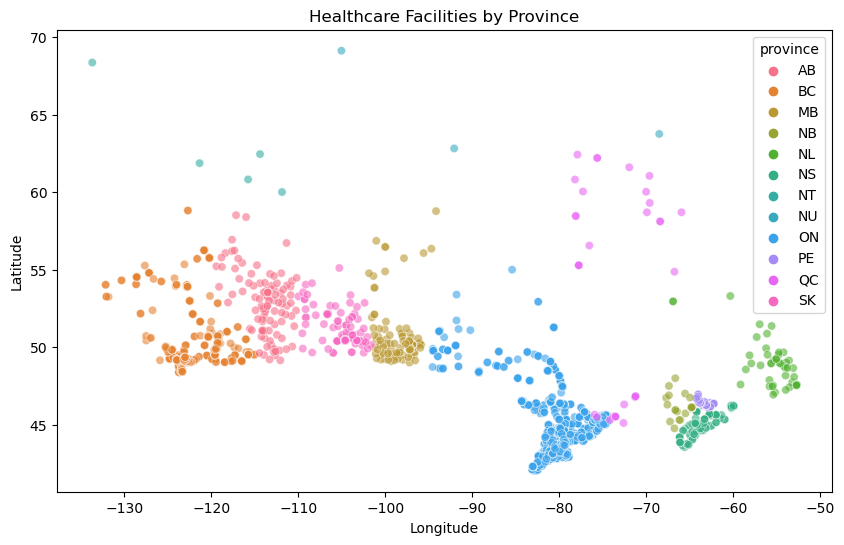

In [23]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="province",
    alpha=0.6
)

plt.title("Healthcare Facilities by Province")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [24]:
df_geo = df.dropna(subset=["latitude", "longitude"])

In [25]:
df_geo.shape

(4571, 16)

In [26]:
df_geo[["latitude","longitude"]].isnull().sum()

latitude     0
longitude    0
dtype: int64

In [27]:
df_geo[["latitude","longitude"]].head(20)

,latitude,longitude
1,51.074582,-114.148426
2,53.351493,-113.730785
3,49.177418,-122.864118
4,49.689998,-115.989647
5,50.677060,-120.329500
6,49.248353,-123.087045
7,50.276153,-119.244537
8,49.030749,-122.358792
9,49.157599,-122.767254
10,49.177735,-122.841799


C:\Users\User\AppData\Local\Temp\ipykernel_8992\3562096902.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_geo["cluster"] = labels


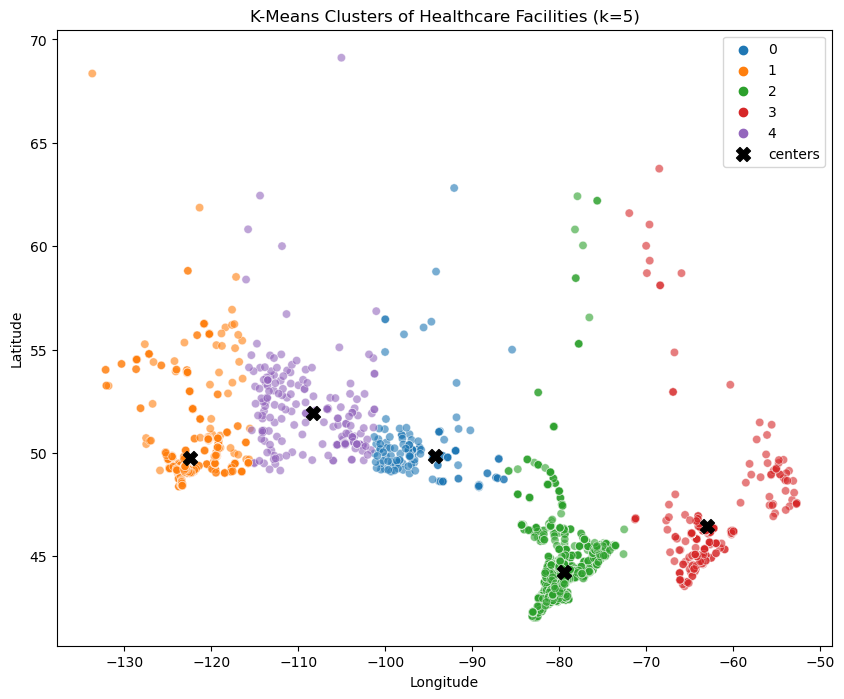

In [28]:
# K-Means clustering on latitude & longitude (k=5) and visualization

coords = df_geo[["latitude", "longitude"]].to_numpy()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(coords)
df_geo["cluster"] = labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_geo,
    x="longitude",
    y="latitude",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    legend="full"
)

# cluster centers (centers are in [latitude, longitude] order)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 0], c="black", s=100, marker="X", label="centers")

plt.title("K-Means Clusters of Healthcare Facilities (k=5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

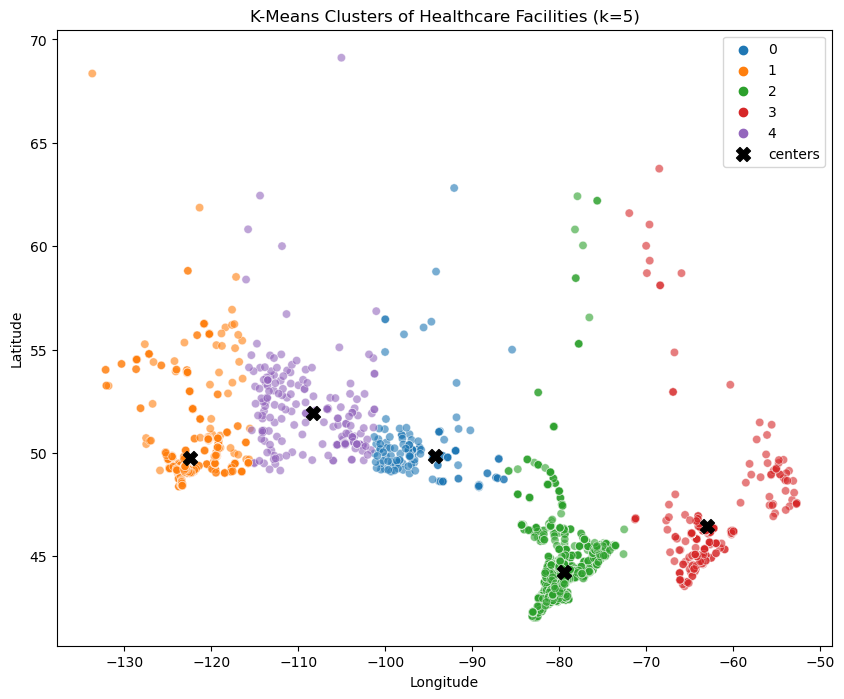

In [29]:
# Avoid SettingWithCopyWarning by making an explicit copy, then assign with .loc
df_geo = df.loc[df["latitude"].notna() & df["longitude"].notna()].copy()

if len(df_geo) == len(labels):
    df_geo.loc[:, "cluster"] = labels
else:
    df_geo.loc[:, "cluster"] = kmeans.predict(df_geo[["latitude", "longitude"]].to_numpy())

    coords = df_geo[["latitude", "longitude"]].to_numpy()

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(coords)
df_geo["cluster"] = labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_geo,
    x="longitude",
    y="latitude",
    hue="cluster",
    palette="tab10",
    alpha=0.6,
    legend="full"
)

# cluster centers (centers are in [latitude, longitude] order)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 0], c="black", s=100, marker="X", label="centers")

plt.title("K-Means Clusters of Healthcare Facilities (k=5)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

In [30]:
df_geo.to_csv("clean_healthcare_facilities.csv", index=False)